In [1]:
import sys
!{sys.executable} -m pip install requests --quiet

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime


# Charger le CSV
file = '/Users/jeanvanbeneden/Documents/Projects/electricity-forecasting/Data/Raw/GUI_ENERGY_PRICES.csv'

df=pd.read_csv(file)


print(f"il y a {len(df)} lignes ds le df")

df.columns
df.head

il y a 30240 lignes ds le df


<bound method NDFrame.head of                                        MTU (UTC)    Area          Sequence  \
0      31/12/2024 23:00:00 - 31/12/2024 23:15:00  BZN|BE  Without Sequence   
1      31/12/2024 23:15:00 - 31/12/2024 23:30:00  BZN|BE  Without Sequence   
2      31/12/2024 23:30:00 - 31/12/2024 23:45:00  BZN|BE  Without Sequence   
3      31/12/2024 23:45:00 - 01/01/2025 00:00:00  BZN|BE  Without Sequence   
4      01/01/2025 00:00:00 - 01/01/2025 00:15:00  BZN|BE  Without Sequence   
...                                          ...     ...               ...   
30235  11/11/2025 21:45:00 - 11/11/2025 22:00:00  BZN|BE  Without Sequence   
30236  11/11/2025 22:00:00 - 11/11/2025 22:15:00  BZN|BE  Without Sequence   
30237  11/11/2025 22:15:00 - 11/11/2025 22:30:00  BZN|BE  Without Sequence   
30238  11/11/2025 22:30:00 - 11/11/2025 22:45:00  BZN|BE  Without Sequence   
30239  11/11/2025 22:45:00 - 11/11/2025 23:00:00  BZN|BE  Without Sequence   

       Day-ahead Price (EUR/MWh) 

In [20]:
df['datetime'] = df['MTU (UTC)'].str.split(' - ').str[0]
df['datetime'] = pd.to_datetime(df['datetime'], format='%d/%m/%Y %H:%M:%S')


df['price'] = df['Day-ahead Price (EUR/MWh)']

df = df.sort_values('datetime').reset_index(drop=True)

df_clean1 = df[['datetime', 'price']].copy()
print(f"\n head \n")


#les prix day ahead sont fixés la veille a midi par h -> j'ai des redondances dans le jeu 
df_clean=df_clean1.resample('1H', on='datetime').first().reset_index()
print(df_clean.head(10))

# Stats
print(f"\n stats \n")
print(f"Prix moyen       : {df_clean['price'].mean():.2f} €/MWh")
print(f"Prix médian      : {df_clean['price'].median():.2f} €/MWh")
print(f"Écart-type       : {df_clean['price'].std():.2f} €/MWh")
print(f"Prix minimum     : {df_clean['price'].min():.2f} €/MWh")
print(f"Prix maximum     : {df_clean['price'].max():.2f} €/MWh")

#prix négatifs
negative_prices = df_clean[df_clean['price'] < 0]

if len(negative_prices) > 0:
    print(f"le plus bas : {negative_prices['price'].min():.2f} €/MWh")
    print(f"date : {negative_prices[negative_prices['price'] == negative_prices['price'].min()]['datetime'].values[0]}")

#prix extrêmes (mu+3sigma)
print(f"\n prix élevés\n")
haut = df_clean['price'].mean() + 3 * df_clean['price'].std()
pique_prix = df_clean[df_clean['price'] > haut]
print(f"pique de prix : {len(pique_prix)} périodes ({len(pique_prix)/len(df_clean)*100:.2f}%)")

output_path = '../data/processed/prices_belgium_clean.csv'
df_clean.to_csv(output_path, index=False)


 head 

             datetime  price
0 2024-12-31 23:00:00  10.62
1 2025-01-01 00:00:00  10.27
2 2025-01-01 01:00:00   8.38
3 2025-01-01 02:00:00   6.61
4 2025-01-01 03:00:00   2.29
5 2025-01-01 04:00:00   3.01
6 2025-01-01 05:00:00   3.52
7 2025-01-01 06:00:00   2.55
8 2025-01-01 07:00:00   4.24
9 2025-01-01 08:00:00   7.50

 stats 

Prix moyen       : 81.85 €/MWh
Prix médian      : 87.05 €/MWh
Écart-type       : 50.51 €/MWh
Prix minimum     : -462.33 €/MWh
Prix maximum     : 517.57 €/MWh
le plus bas : -462.33 €/MWh
date : 2025-05-11T11:00:00.000000000

 prix élevés

pique de prix : 32 périodes (0.42%)


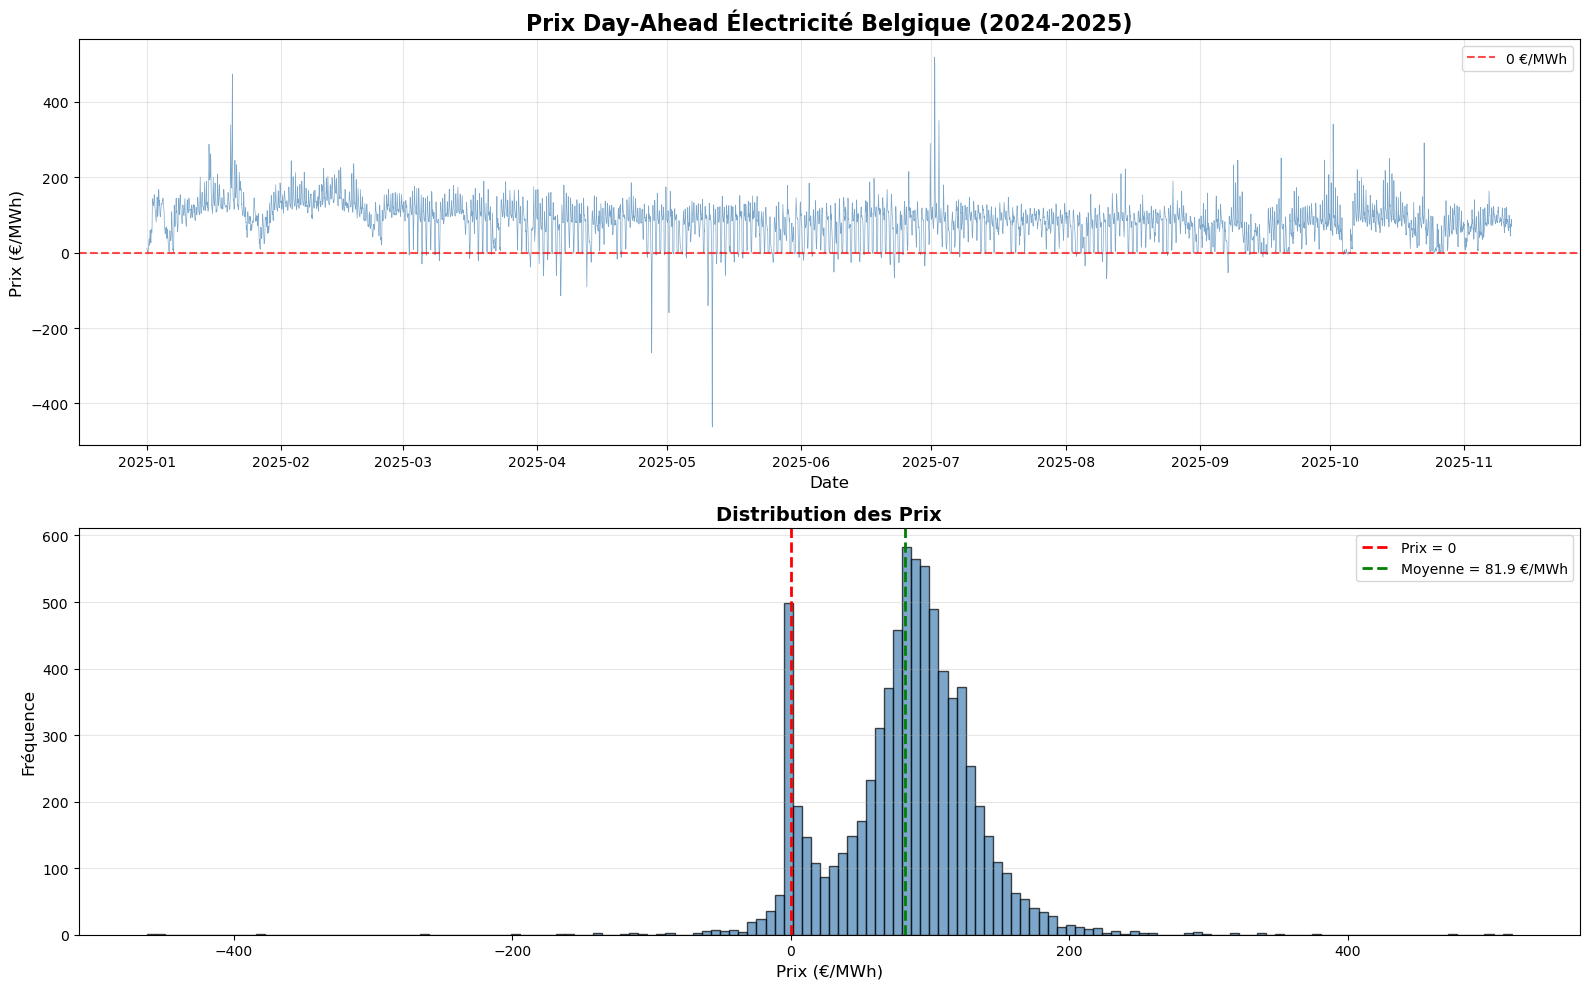

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(df_clean['datetime'], df_clean['price'], 
             linewidth=0.5, alpha=0.7, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5, 
                alpha=0.7, label='0 €/MWh')
axes[0].set_title('Prix Day-Ahead Électricité Belgique (2024-2025)', 
                  fontsize=16, fontweight='bold')
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Prix (€/MWh)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)


axes[1].hist(df_clean['price'], bins=150, color='steelblue', alpha=0.7, edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Prix = 0')
axes[1].axvline(x=df_clean['price'].mean(), color='green', linestyle='--', 
                linewidth=2, label=f'Moyenne = {df_clean["price"].mean():.1f} €/MWh')
axes[1].set_title('Distribution des Prix', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Prix (€/MWh)', fontsize=12)
axes[1].set_ylabel('Fréquence', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


on voit ici que les prix sont : - volatils (logique)
                                - il y a des prix négatifs (-> trop de d'en ??)
                                - il y a bien des pics extrêmes
                            

In [23]:
df_clean['hour'] = df_clean['datetime'].dt.hour
df_clean['day_of_week'] = df_clean['datetime'].dt.dayofweek  # 0=lun 6=dim
df_clean['day_name'] = df_clean['datetime'].dt.day_name()
df_clean['month'] = df_clean['datetime'].dt.month
df_clean['month_name'] = df_clean['datetime'].dt.month_name()
df_clean['year'] = df_clean['datetime'].dt.year
df_clean['is_weekend'] = df_clean['day_of_week'].isin([5, 6]).astype(int)

mean_price = df_clean['price'].mean()
std_price = df_clean['price'].std()

In [42]:
def classify_price(price):
    if price <0 : return 'negative'
    elif price < 25 : return 'very low'
    elif price<75 : return 'normal'
    elif price<150 : return 'high'
    else : return 'spike'

In [43]:
df_clean['class']=df_clean['price'].apply(lambda x: classify_price(x))

In [44]:
df_clean.head

<bound method NDFrame.head of                 datetime  price  hour  day_of_week   day_name  month  \
0    2024-12-31 23:00:00  10.62    23            1    Tuesday     12   
1    2025-01-01 00:00:00  10.27     0            2  Wednesday      1   
2    2025-01-01 01:00:00   8.38     1            2  Wednesday      1   
3    2025-01-01 02:00:00   6.61     2            2  Wednesday      1   
4    2025-01-01 03:00:00   2.29     3            2  Wednesday      1   
...                  ...    ...   ...          ...        ...    ...   
7555 2025-11-11 18:00:00  67.43    18            1    Tuesday     11   
7556 2025-11-11 19:00:00  88.23    19            1    Tuesday     11   
7557 2025-11-11 20:00:00  85.32    20            1    Tuesday     11   
7558 2025-11-11 21:00:00  88.12    21            1    Tuesday     11   
7559 2025-11-11 22:00:00  72.06    22            1    Tuesday     11   

     month_name  year  is_weekend     class  
0      December  2024           0  very low  
1       Janua

In [45]:
regime_stats = df_clean.groupby('class').agg({'price': ['count', 'mean', 'std', 'min', 'max']}).round(2)
regime_stats.columns = ['count', 'mean', 'std', 'min', 'max']
regime_stats['percentage'] = (regime_stats['count'] / len(df_clean) * 100).round(2)
regime_order = ['negative', 'very low', 'normal', 'high', 'spike']
regime_stats = regime_stats.reindex(regime_order)

In [46]:
print(regime_stats)

          count    mean    std     min     max  percentage
class                                                     
negative    517  -14.11  41.05 -462.33   -0.01        6.84
very low    664    8.36   7.45    0.00   24.94        8.78
normal     1595   56.49  13.64   25.00   74.99       21.10
high       4350  103.91  18.99   75.00  149.95       57.54
spike       434  180.67  42.63  150.00  517.57        5.74


In [48]:
hourly_stats = df_clean.groupby('hour')['price'].agg(['mean', 'median', 'std', 'min', 'max', 'count']).round(2)
print(hourly_stats)

        mean  median    std     min     max  count
hour                                              
0      79.99   84.12  28.38   -2.77  147.08    315
1      76.70   81.51  28.49   -4.54  138.44    315
2      75.15   80.43  28.04   -4.68  131.64    315
3      76.99   83.09  28.47   -4.65  132.88    315
4      85.90   92.99  31.44   -3.86  140.87    315
5      96.71  103.00  36.31   -0.81  185.00    315
6     103.98  104.90  43.91    0.00  220.07    315
7      94.46   94.31  54.60   -0.50  338.48    315
8      73.39   76.36  54.30  -12.01  289.94    315
9      57.54   59.99  53.26  -86.91  261.94    315
10     44.15   45.48  60.08 -450.00  221.55    315
11     35.59   27.97  62.66 -462.33  201.44    315
12     33.57   24.94  57.36 -378.67  192.81    315
13     41.29   37.86  48.22 -110.00  212.11    315
14     53.59   55.91  45.93  -35.97  239.34    315
15     73.50   73.74  41.80  -10.30  294.08    315
16    100.22   96.85  39.74   -2.25  379.99    315
17    127.42  119.18  47.17    

In [56]:
peak_hours = hourly_stats.nlargest(3, 'mean')
off_peak_hours = hourly_stats.nsmallest(3, 'mean')

print(f"peak hours \n")
for hour in peak_hours.index:
    print(f"{hour}h : {peak_hours.loc[hour, 'mean']:.2f}")
    
print(f"\noff peak hours \n")
for hour in off_peak_hours.index:
    print(f"{hour}h : {off_peak_hours.loc[hour, 'mean']:.2f}")

peak hours 

18h : 134.29
17h : 127.42
19h : 121.07

off peak hours 

12h : 33.57
11h : 35.59
13h : 41.29


In [60]:
day_names_fr = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
weekly_stats = df_clean.groupby('day_of_week')['price'].agg(['mean', 'median', 'std', 'count']).round(2)

for idx, day in enumerate(day_names_fr):
    print(f"{day} : {weekly_stats.loc[idx, 'mean']} €/MWh (std: {weekly_stats.loc[idx, 'std']:})")


weekend_mean =df_clean[df_clean['is_weekend'] == 1]['price'].mean()
weekday_mean=df_clean[df_clean['is_weekend'] == 0]['price'].mean()

print(f"\nweekday mean : {weekday_mean:.2f} €/MWh")
print(f"weekend mean: {weekend_mean:.2f} €/MWh")
print(f"diff: {weekend_mean - weekday_mean:+.2f} €/MWh")

Lundi : 86.74 €/MWh (std: 52.43)
Mardi : 88.52 €/MWh (std: 51.34)
Mercredi : 93.24 €/MWh (std: 48.21)
Jeudi : 88.33 €/MWh (std: 43.26)
Vendredi : 86.02 €/MWh (std: 42.44)
Samedi : 69.76 €/MWh (std: 47.55)
Dimanche : 60.33 €/MWh (std: 58.0)

weekday mean : 88.57 €/MWh
weekend mean: 65.05 €/MWh
diff: -23.52 €/MWh


In [62]:
monthly_stats = df_clean.groupby('month')['price'].agg(['mean', 'median', 'std', 'count']).round(2)
month_names_fr = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc']

for idx, month_name in enumerate(month_names_fr, start=1):
    if idx in monthly_stats.index:
        print(f"{month_name} : {monthly_stats.loc[idx, 'mean']} €/MWh")

Jan : 112.17 €/MWh
Fév : 128.73 €/MWh
Mar : 91.17 €/MWh
Avr : 73.36 €/MWh
Mai : 61.08 €/MWh
Juin : 65.36 €/MWh
Juil : 83.06 €/MWh
Août : 68.89 €/MWh
Sep : 63.68 €/MWh
Oct : 76.45 €/MWh
Nov : 75.58 €/MWh
Déc : 10.62 €/MWh


In [63]:
df_clean.head(-10)

,datetime,price,hour,day_of_week,day_name,month,month_name,year,is_weekend,class
0,2024-12-31 23:00:00,10.62,23,1,Tuesday,12,December,2024,0,very low
1,2025-01-01 00:00:00,10.27,0,2,Wednesday,1,January,2025,0,very low
2,2025-01-01 01:00:00,8.38,1,2,Wednesday,1,January,2025,0,very low
3,2025-01-01 02:00:00,6.61,2,2,Wednesday,1,January,2025,0,very low
4,2025-01-01 03:00:00,2.29,3,2,Wednesday,1,January,2025,0,very low
...,...,...,...,...,...,...,...,...,...,...
7545,2025-11-11 08:00:00,98.32,8,1,Tuesday,11,November,2025,0,high
7546,2025-11-11 09:00:00,91.36,9,1,Tuesday,11,November,2025,0,high
7547,2025-11-11 10:00:00,75.97,10,1,Tuesday,11,November,2025,0,high
7548,2025-11-11 11:00:00,66.98,11,1,Tuesday,11,November,2025,0,normal


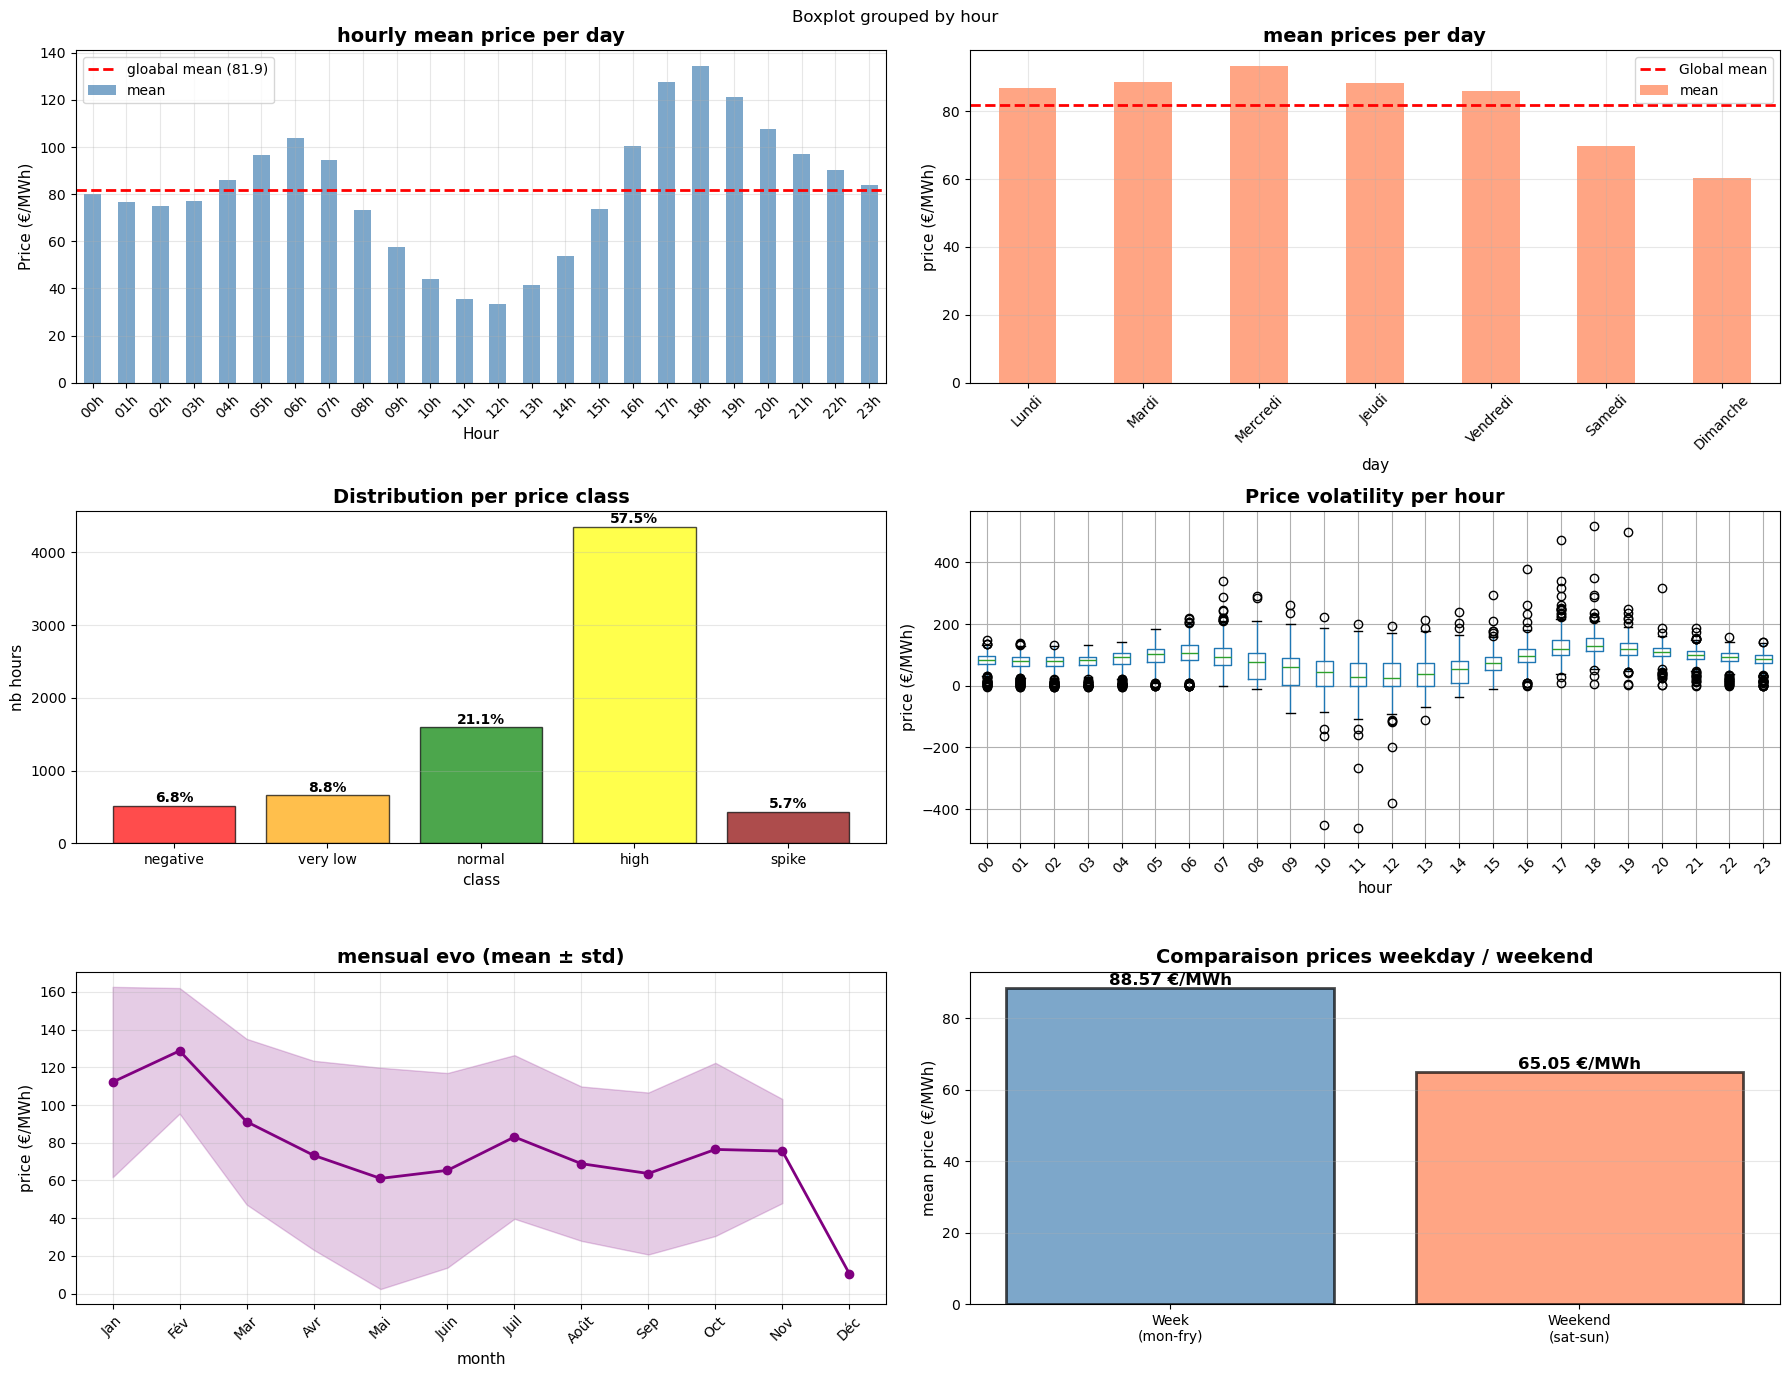

In [75]:
#visu

plt.rcParams['figure.figsize'] = (16, 12)
fig1, axes = plt.subplots(3, 2, figsize=(18, 14))

ax1 = axes[0, 0]
hourly_stats['mean'].plot(kind='bar', ax=ax1, color='steelblue', alpha=0.7)
ax1.axhline(y=mean_price, color='red', linestyle='--', linewidth=2, label=f'gloabal mean ({mean_price:.1f})')
ax1.set_title('hourly mean price per day', fontsize=14, fontweight='bold')
ax1.set_xlabel('Hour', fontsize=11)
ax1.set_ylabel('Price (€/MWh)', fontsize=11)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticklabels([f'{h:02d}h' for h in range(24)], rotation=45)


ax2 = axes[0, 1]
weekly_stats['mean'].plot(kind='bar', ax=ax2, color='coral', alpha=0.7)
ax2.axhline(y=mean_price, color='red', linestyle='--', linewidth=2, label=f'Global mean')
ax2.set_title('mean prices per day', fontsize=14, fontweight='bold')
ax2.set_xlabel('day', fontsize=11)
ax2.set_ylabel('price (€/MWh)', fontsize=11)
ax2.set_xticklabels(day_names_fr, rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3)


ax3 = axes[1, 0]
regime_counts = df_clean['class'].value_counts().reindex(regime_order)
colors_regime = {'negative': 'red', 'very low': 'orange', 'normal': 'green', 'high': 'yellow', 'spike': 'darkred'}
ax3.bar(regime_order, regime_counts, color=[colors_regime[r] for r in regime_order], alpha=0.7, edgecolor='black')
ax3.set_title('Distribution per price class', fontsize=14, fontweight='bold')
ax3.set_xlabel('class', fontsize=11)
ax3.set_ylabel('nb hours', fontsize=11)
ax3.grid(True, alpha=0.3, axis='y')
for i, (regime, count) in enumerate(zip(regime_order, regime_counts)):
    pct = count / len(df_clean) * 100
    ax3.text(i, count + 50, f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')


ax4 = axes[1, 1]
df_clean.boxplot(column='price', by='hour', ax=ax4, grid=True)
ax4.set_title('Price volatility per hour', fontsize=14, fontweight='bold')
ax4.set_xlabel('hour', fontsize=11)
ax4.set_ylabel('price (€/MWh)', fontsize=11)
plt.sca(ax4)
plt.xticks([i+1 for i in range(24)], [f'{h:02d}' for h in range(24)], rotation=45)


ax5 = axes[2, 0]
monthly_stats['mean'].plot(kind='line', marker='o', ax=ax5, color='purple', linewidth=2)
ax5.fill_between(monthly_stats.index, monthly_stats['mean'] - monthly_stats['std'],monthly_stats['mean'] + monthly_stats['std'],alpha=0.2, color='purple')
ax5.set_title('mensual evo (mean ± std)', fontsize=14, fontweight='bold')
ax5.set_xlabel('month', fontsize=11)
ax5.set_ylabel('price (€/MWh)', fontsize=11)
ax5.set_xticks(range(1, 13))
ax5.set_xticklabels(month_names_fr, rotation=45)
ax5.grid(True, alpha=0.3)


ax6 = axes[2, 1]
weekend_data = [weekday_mean, weekend_mean]
bars = ax6.bar(['Week\n(mon-fry)', 'Weekend\n(sat-sun)'], weekend_data, color=['steelblue', 'coral'], alpha=0.7, edgecolor='black', linewidth=2)
ax6.set_title('Comparaison prices weekday / weekend', fontsize=14, fontweight='bold')
ax6.set_ylabel('mean price (€/MWh)', fontsize=11)
ax6.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, weekend_data):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f} €/MWh', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [82]:
print(f"""
PERIOD
  -begining: {df_clean['datetime'].min()}
  -end : {df_clean['datetime'].max()}
  -hrs nb: {len(df_clean):,}
  -day nb:{len(df_clean) / 24:.1f}

GLOB STATS
  -mean price: {df_clean['price'].mean():.2f} €/MWh
  -median: {df_clean['price'].median():.2f} €/MWh
  -std: {df_clean['price'].std():.2f} €/MWh
  -min: {df_clean['price'].min():.2f} €/MWh
  -max: {df_clean['price'].max():.2f} €/MWh

PRICE CLASS
  -neg: {len(df_clean[df_clean['class'] == 'negative'])} hrs ({len(df_clean[df_clean['class'] == 'negative'])/len(df_clean)*100:.2f}%)
  -very low: {len(df_clean[df_clean['class'] == 'very low'])} hrs ({len(df_clean[df_clean['class'] == 'very low'])/len(df_clean)*100:.2f}%)
  -norm: {len(df_clean[df_clean['class'] == 'normal'])} hrs ({len(df_clean[df_clean['class'] == 'normal'])/len(df_clean)*100:.2f}%)
  -high: {len(df_clean[df_clean['class'] == 'high'])} hrs ({len(df_clean[df_clean['class'] == 'high'])/len(df_clean)*100:.2f}%)
  -spikes: {len(df_clean[df_clean['class'] == 'spike'])} hrs ({len(df_clean[df_clean['class'] == 'spike'])/len(df_clean)*100:.2f}%)

PATTERNS
  -most expensive hr: {hourly_stats['mean'].idxmax():02d}h ({hourly_stats['mean'].max():.2f} €/MWh)
  -less // : {hourly_stats['mean'].idxmin():02d}h ({hourly_stats['mean'].min():.2f} €/MWh)
  -weekday price: {weekday_mean:.2f} €/MWh
  -weekend price: {weekend_mean:.2f} €/MWh
  -diff : {weekend_mean - weekday_mean:+.2f} €/MWh

OBSERVATIONS
  -negative prices
  -extreme spikes
  -hourly patterns
  -weekend effect
  -High volatility
""")


PERIOD
  -begining: 2024-12-31 23:00:00
  -end : 2025-11-11 22:00:00
  -hrs nb: 7,560
  -day nb:315.0

GLOB STATS
  -mean price: 81.85 €/MWh
  -median: 87.05 €/MWh
  -std: 50.51 €/MWh
  -min: -462.33 €/MWh
  -max: 517.57 €/MWh

PRICE CLASS
  -neg: 517 hrs (6.84%)
  -very low: 664 hrs (8.78%)
  -norm: 1595 hrs (21.10%)
  -high: 4350 hrs (57.54%)
  -spikes: 434 hrs (5.74%)

PATTERNS
  -most expensive hr: 18h (134.29 €/MWh)
  -less // : 12h (33.57 €/MWh)
  -weekday price: 88.57 €/MWh
  -weekend price: 65.05 €/MWh
  -diff : -23.52 €/MWh

OBSERVATIONS
  -negative prices
  -extreme spikes
  -hourly patterns
  -weekend effect
  -High volatility

